## Section 1: Sampling Distribution Reasoning

### graphing the distribution of β^​

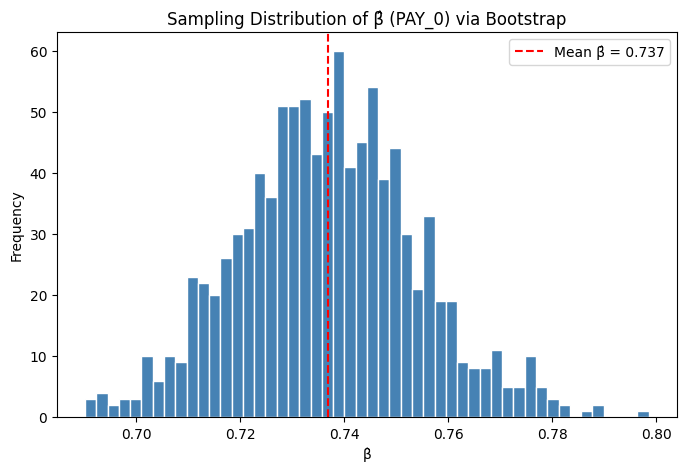

Mean of β̂:  0.7368
Std of β̂:   0.0172


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('cleaned_default_data.csv')

X = df[['PAY_0']]
y = df['default payment next month']

# ── Bootstraps───────────────────────────
n_bootstrap = 1000
beta_estimates = []

for _ in range(n_bootstrap):
    sample = df.sample(n=len(df), replace=True)
    X_sample = sample[['PAY_0']]
    y_sample = sample['default payment next month']

    model = LogisticRegression()
    model.fit(X_sample, y_sample)
    beta_estimates.append(model.coef_[0][0])

# ── graphing β̂ ─────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.hist(beta_estimates, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.mean(beta_estimates), color='red',
            linestyle='--', label=f'Mean β̂ = {np.mean(beta_estimates):.3f}')
plt.title('Sampling Distribution of β̂ (PAY_0) via Bootstrap')
plt.xlabel('β̂')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"Mean of β̂:  {np.mean(beta_estimates):.4f}")
print(f"Std of β̂:   {np.std(beta_estimates):.4f}")

Under 1000 times bootstraps with the logistic regression. The distribution of β̂ is appears mostly symmetric, the mean is 0.73, and the STD is 0.0172, which provide the statistic evidence that the distribution of β̂ with large sample size is symmetric.

## Section 2 Confidence Intervals

### Theory-based CI

In [3]:
import statsmodels.api as sm

# ── 1. Theory-based CI（asume its perfect symmetric）─────────────────
X_with_const = sm.add_constant(X)  # statsmodels add intercept
model_sm = sm.Logit(y, X_with_const)
result = model_sm.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.475553
         Iterations 6
                               Logit Regression Results                               
Dep. Variable:     default payment next month   No. Observations:                29965
Model:                                  Logit   Df Residuals:                    29963
Method:                                   MLE   Df Model:                            1
Date:                        Sat, 11 Apr 2026   Pseudo R-squ.:                  0.1002
Time:                                21:22:58   Log-Likelihood:                -14250.
converged:                               True   LL-Null:                       -15836.
Covariance Type:                    nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4021      0.016    -89.858 

### 1000 Boostrap CI

Bootstrap CI: [0.7040, 0.7743]
Theory-based CI: [0.7100, 0.7660]
Bootstrap Mean: 0.7368


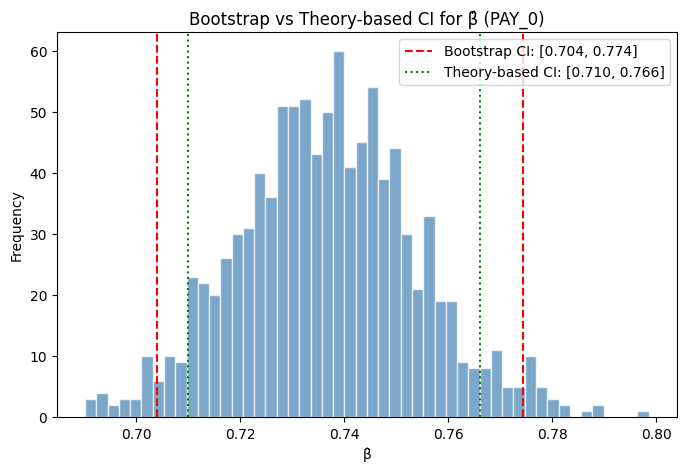

In [4]:
# ── Bootstrap CI (use the bootstrap from section 1) ─────────────────────────────────────────
lower = np.percentile(beta_estimates, 2.5)
upper = np.percentile(beta_estimates, 97.5)

print(f"Bootstrap CI: [{lower:.4f}, {upper:.4f}]")
print(f"Theory-based CI: [0.7100, 0.7660]")
print(f"Bootstrap Mean: {np.mean(beta_estimates):.4f}")


plt.figure(figsize=(8, 5))
plt.hist(beta_estimates, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
plt.axvline(lower, color='red', linestyle='--', label=f'Bootstrap CI: [{lower:.3f}, {upper:.3f}]')
plt.axvline(upper, color='red', linestyle='--')
plt.axvline(0.710, color='green', linestyle=':', label='Theory-based CI: [0.710, 0.766]')
plt.axvline(0.766, color='green', linestyle=':')
plt.title('Bootstrap vs Theory-based CI for β̂ (PAY_0)')
plt.xlabel('β̂')
plt.ylabel('Frequency')
plt.legend()
plt.show()

By constructed the Theory-based CI [0.710, 0.766] and the Bootstrap CI [0.704, 0.774], we can say that the Boostrap CI is a little bit wider than Theory-based CI. But both CIs do not include 0, which means that the repayment history is a strong predictor of default rate.

## Section 3 Hypothesis Testing

In [5]:
beta_hat = result.params['PAY_0']
se = result.bse['PAY_0']

z_stat = beta_hat / se
p_value = result.pvalues['PAY_0']

print(f"β̂:       {beta_hat:.4f}")
print(f"SE:      {se:.4f}")
print(f"z-stat:  {z_stat:.4f}")
print(f"p-value: {p_value:.4e}")

β̂:       0.7376
SE:      0.0143
z-stat:  51.6268
p-value: 0.0000e+00



To formally test whether repayment history has a statistically significant effect on default probability, we conducted a hypothesis test:

$$H_0: \beta_{PAY\_0} = 0 \quad \text{(no effect)}$$

$$H_1: \beta_{PAY\_0} \neq 0 \quad \text{(significant effect)}$$

The z-statistic of 51.63 indicates that our estimate is over 51 standard deviations away from zero, making it virtually impossible to attribute to random chance. The corresponding p-value of approximately 0 is far below the significance level of $\alpha = 0.05$, leading us to reject $H_0$. This result is consistent with our findings in Section 2, where both CIs excluded zero. Together, the evidence strongly suggests that repayment delay status is a significant predictor of default probability.

## Section 4 Interpreation

In this part, we constructed two different CI, the theory-based CI, assume the 𝛽 is perfectly symmetric, the interval is [0.710, 0.766]. Also the Bootstrap CI [0.704, 0.774], with 1000 times Bootstrap with logistic regression. The Theory-Based CI is a little bit narrower than the Bootstraps one, since it is hypothesising. But both CIs are not include 0, which provide the solid evidence that the repayment history is a strong predictor for default behavior.

The z-statistic (51.63) and p-value (approximately 0) provide strong support to let us reject the null hypothesis. From a practical standpoint, banks can leverage this finding to flag high-risk customers early — those with repeated payment delays should be prioritized for intervention, such as credit limit reductions or payment reminders, since the 𝛽 from MLE is 0.7376. However, it is worth noting that this model relies solely on PAY_0, and real-world credit risk involves many additional factors beyond repayment history alone.

